In [896]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [897]:
df=pd.read_csv("C:\\Users\\mohd abdul khaleq b\\Downloads\\Loan_Data.csv")

In [898]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [899]:
df.shape

(614, 13)

In [900]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [901]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [902]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [903]:
pd.crosstab(df['Credit_History'], df['Loan_Status'], margins= True)

Loan_Status,N,Y,All
Credit_History,,,
0.0,82,7,89
1.0,97,378,475
All,179,385,564


* Applicants with credit history of 1 are more eligible than who have 0 

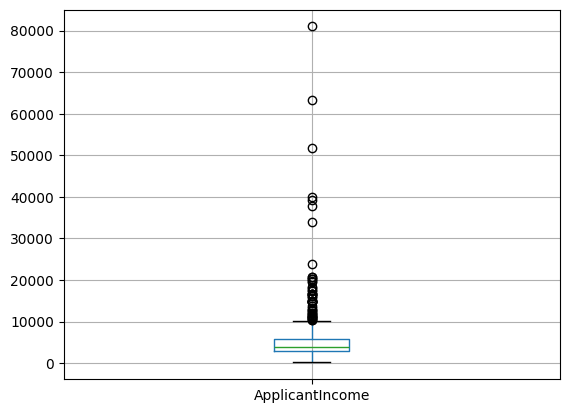

In [904]:
df.boxplot(column= "ApplicantIncome")
plt.show()

* we can see that there are lots of outliers in ApplicantIncome

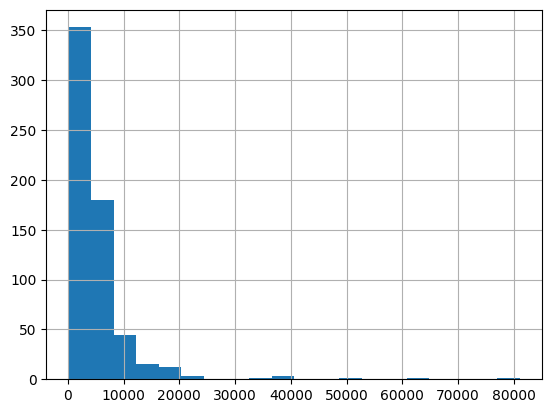

In [905]:
df['ApplicantIncome'].hist(bins=20)
plt.show()

* It is clearly right skewed

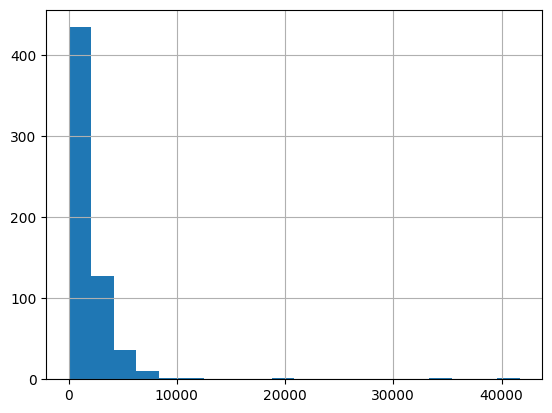

In [906]:
df['CoapplicantIncome'].hist(bins=20)
plt.show()

* This is also rightly skewed

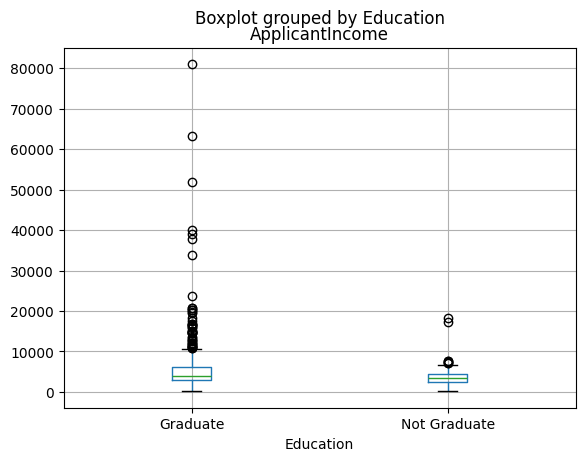

In [907]:
df.boxplot(column='ApplicantIncome', by='Education')
plt.show()

* Some of the applicant who are Graduate have very high salary compared to Not Graduate

<Axes: >

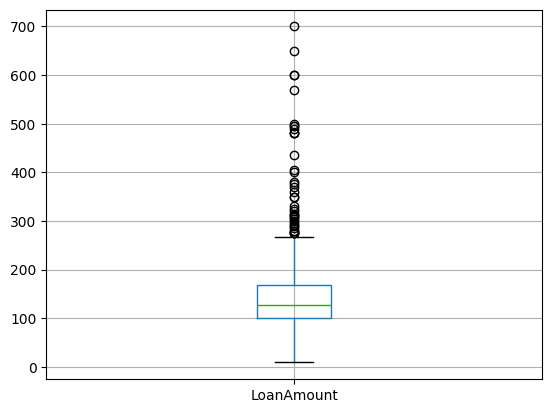

In [908]:
df.boxplot(column= 'LoanAmount')

* Loan Amount also has lots of Outliers 

<Axes: >

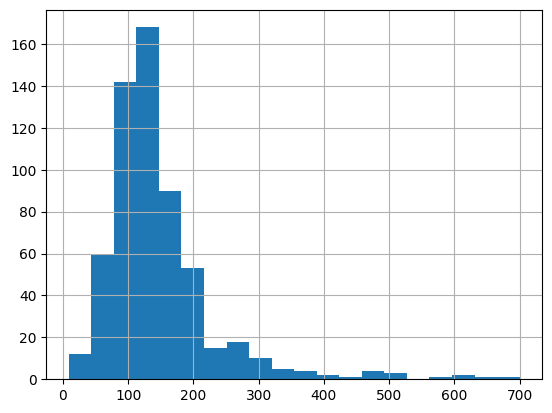

In [909]:
df['LoanAmount'].hist(bins=20)

* Loan Amount is also rightly skewed

In [910]:
df['LoanAmount']=np.log(df['LoanAmount'])

<Axes: >

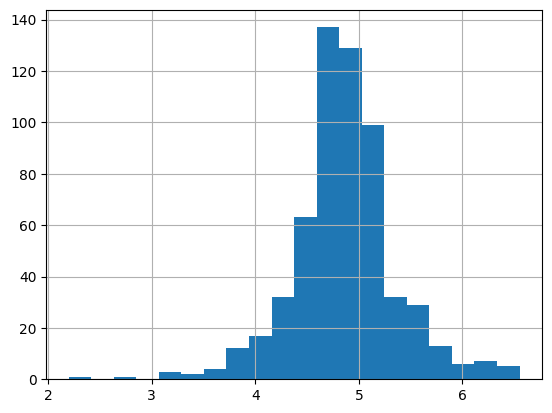

In [911]:
df['LoanAmount'].hist(bins=20)

* This looks alot normalized now

In [912]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [913]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [914]:
df['Gender'].fillna(df['Gender'].mode()[0],inplace= True)


C:\Users\mohd abdul khaleq b\AppData\Local\Temp\ipykernel_32988\2403398487.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0],inplace= True)


In [915]:
df['Married'].fillna(df['Married'].mode() [0], inplace= True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace= True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace= True)

C:\Users\mohd abdul khaleq b\AppData\Local\Temp\ipykernel_32988\2531097644.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Married'].fillna(df['Married'].mode() [0], inplace= True)
C:\Users\mohd abdul khaleq b\AppData\Local\Temp\ipykernel_32988\2531097644.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

In [916]:
df.LoanAmount= df.LoanAmount.fillna(df.LoanAmount.mean())


In [917]:
df.LoanAmount=df.LoanAmount.fillna(df.LoanAmount.mean())

In [918]:
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace= True)

C:\Users\mohd abdul khaleq b\AppData\Local\Temp\ipykernel_32988\2293509372.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace= True)


In [919]:
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace= True)

C:\Users\mohd abdul khaleq b\AppData\Local\Temp\ipykernel_32988\449244352.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace= True)


In [920]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [921]:
df['TotalIncome']=df['ApplicantIncome'] + df['CoapplicantIncome']

In [922]:
df['TotalIncome']=np.log(df['TotalIncome'])

<Axes: >

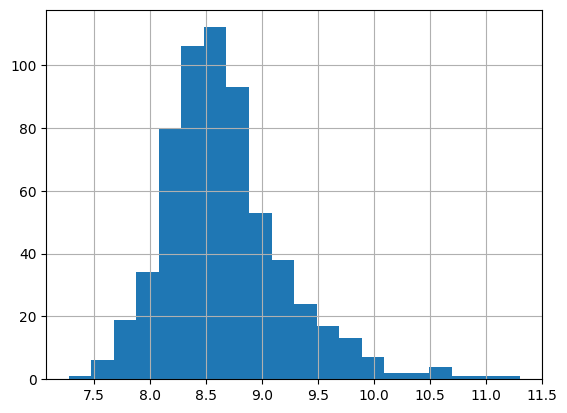

In [923]:
df['TotalIncome'].hist(bins=20)

In [924]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status',
       'TotalIncome'],
      dtype='object')

In [925]:


df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Gender'] = df['Gender'].astype(int)


In [926]:
df['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [927]:
df['Property_Area'] = df['Property_Area'].map({'Urban': 1, 'Rural': 0, 'Semiurban': 2})
df['Property_Area'] = df['Property_Area'].astype(int)

In [928]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    int64  
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    int64  
 12  Loan_Status        614 non-null    object 
 13  TotalIncome        614 non-null    float64
dtypes: float64(5), int64(3), object(6)
memory usage: 67.3+ KB


In [929]:
df = df.drop(['ApplicantIncome', 'CoapplicantIncome','Loan_ID'], axis=1)

In [930]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [931]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()

categorical_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']

for col in categorical_cols:
    X_train[col] = label.fit_transform(X_train[col].astype(str))
    X_test[col]  = label.transform(X_test[col].astype(str))

In [932]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

X_train_scaled = ss.fit_transform(X_train)
X_test_scaled  = ss.transform(X_test)

In [933]:
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(X_train.shape)
print(X_test.shape)
print(X_train.columns)


(491, 10)
(123, 10)
Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'TotalIncome'],
      dtype='object')


In [934]:
from sklearn.tree import DecisionTreeClassifier

In [935]:
DTC=DecisionTreeClassifier(criterion='entropy', random_state=0)

In [936]:
DTC.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [937]:
y_pred=DTC.predict(X_test)

In [938]:
y_pred

array(['Y', 'Y', 'N', 'N', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'N',
       'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'N', 'N', 'N', 'N', 'N', 'Y',
       'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'N', 'N', 'N', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'N', 'Y',
       'Y', 'N', 'Y', 'N', 'N', 'Y'], dtype=object)

In [939]:
from sklearn import metrics

In [940]:
print("The Accuracy of Decision Tree is",metrics.accuracy_score(y_pred, y_test))

The Accuracy of Decision Tree is 0.6747967479674797


In [941]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [942]:
print("The Accuracy of Decision Tree is",metrics.accuracy_score(y_pred, y_test))

The Accuracy of Decision Tree is 0.8292682926829268
